In [33]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import copy

In [17]:
@dataclass
class Pin:
    local_pos: np.ndarray
    net: str

@dataclass
class Component:
    id: str
    pos: np.ndarray
    theta: float = 0.0
    half_size: np.ndarray = field(default_factory=lambda: np.array([2.5, 2.5]))
    pins: list = field(default_factory=list)

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def pin_world(component, pin):
    return component.pos + rot(component.theta) @ pin.local_pos

def rebuild_nets(components):
    nets = {}
    for cid, comp in components.items():
        for pi, pin in enumerate(comp.pins):
            nets.setdefault(pin.net, []).append((cid, pi))
    return nets

In [27]:
def hpwl(components):
    total = 0.0
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        pts = np.array([pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members])
        total += np.ptp(pts[:, 0]) + np.ptp(pts[:, 1])
    return total
hpwl(components)

np.float64(34.5)

In [32]:
def attractive(components, nets):
    F = {cid: np.zeros(2) for cid in components}
    for members in nets.values():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)
        for (cid, _), p in zip(members, pts):
            F[cid] += ctr - p
    return F
attractive(components, rebuild_nets(components))

{'U1': array([15.  ,  1.25]), 'R1': array([-15.  ,  -1.25])}

In [52]:
# TODO loop attract and repulse together?
def repulsive(components, k=30.0, slop=0.4):
    F = {cid: np.zeros(2) for cid in components}
    ids = list(components)
    for i in range(len(ids)):
        a = componnents[ids[i]]
        for j in range(i + 1, len(ids)):
            b = components[ids[j]]
            dx, dy = b.pos - a.pos
            ox = a.half_size[0] + b.half_size[0] + slop - abs(dx)
            oy = a.half_size[1] + b.half_size[1] + slop - abs(dy)
            if ox <= 0 or oy <= 0:
                continue
            if ox < oy:
                push = np.array([np.sign(dx or 1) * ox * k, 0.0])
            else:
                push = np.array([0.0, np.sign(dy or 1) * oy * k])
            F[ids[i]] -= push
            F[ids[j]] += push
    return F
repulsive(components, 

In [50]:
board = np.array([[0,0], [30, 0], [30, 20], [15, 20], [15, 10], [0, 10]], float)

components = {
    "U1": Component("U1", np.array([5.0, 5.0]), half_size=np.array([3.0, 3.0]),
                    pins=[Pin(np.array([-2.5, 2.5]), "VCC"),
                          Pin(np.array([-2.5, -2.5]), "GND"),
                          Pin(np.array([2.5, 0.0]), "SIG")]),
    "R1": Component("R1", np.array([20.0, 5.0]), theta=np.pi/2,
                    half_size=np.array([1.0, 0.4]),
                    pins=[Pin(np.array([-1.0, 0]), "SIG"),
                          Pin(np.array([1.0, 0]), "GND")]),
}

rebuild_nets(components)

{'VCC': [('U1', 0)],
 'GND': [('U1', 1), ('R1', 1)],
 'SIG': [('U1', 2), ('R1', 0)]}

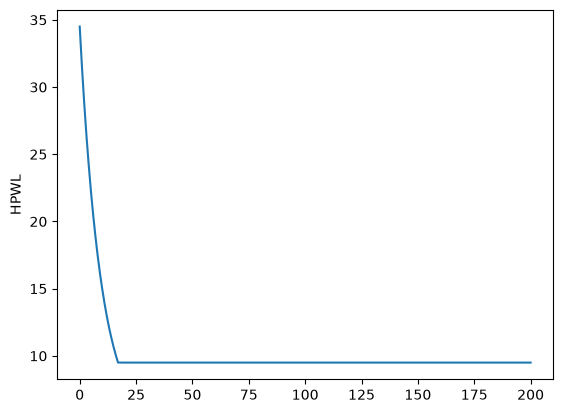

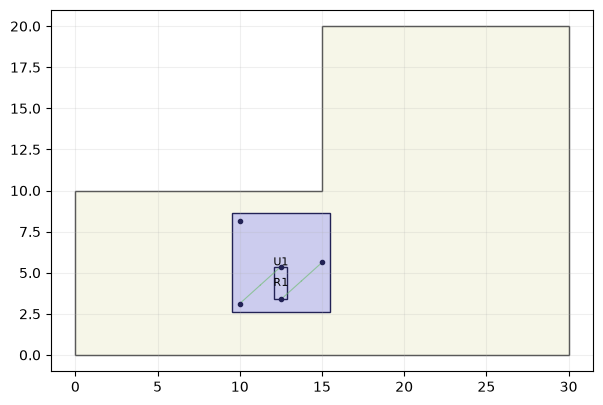

In [51]:
def step(components, dt=0.05):
    nets = rebuild_nets(components)
    F = attractive(components, nets)
    for cid, c in components.items():
        c.pos = c.pos + dt * F[cid]

history = [hpwl(components)]
components_copy = copy.deepcopy(components)
for _ in range(200):
    step(components_copy)
    history.append(hpwl(components_copy))

plt.plot(history); plt.ylabel("HPWL"); plt.show()
draw(components_copy, board)

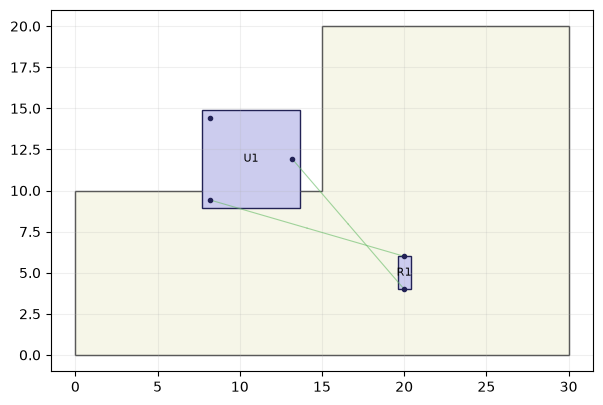

In [47]:
def draw(components, board):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_aspect("equal")
    ax.add_patch(patches.Polygon(board, facecolor="#f6f6e8", edgecolor="#444"))
    # draw ratsnest as star
    for net, members in rebuild_nets(components).items():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)  # centroid
        for p in pts: ax.plot([p[0], ctr[0]], [p[1], ctr[1]], "-", color="#6b6", alpha=0.6, lw=0.8)
    # draw components
    for cid, c in components.items():
        box = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) * c.half_size
        corners = (rot(c.theta) @ box.T).T + c.pos
        ax.add_patch(patches.Polygon(corners, facecolor="#cce", edgecolor="#225"))
        ax.text(*c.pos, cid, ha="center", va="center", fontsize=8)
        for p in c.pins:
            ax.plot(*pin_world(c, p), "o", color="#225", markersize=3)
    ax.autoscale_view()
    ax.grid(alpha=0.2)
    plt.show()

draw(components, board)